<a href="https://colab.research.google.com/github/honeylouluzon/Guided-Project-AI-ML-DataScience/blob/main/Explore_data_for_data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Science in Microsoft Fabric
https://github.com/MicrosoftLearning/mslearn-fabric/tree/main/Instructions/Labs$0

##LAB 8a to 8d

###Imports

In [ ]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler


### Get the Data

In [ ]:
url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"

df = pd.read_csv(url, sep="\t")
print(df.head())

   AGE  SEX   BMI     BP   S1     S2    S3   S4      S5  S6    Y
0   59    2  32.1  101.0  157   93.2  38.0  4.0  4.8598  87  151
1   48    1  21.6   87.0  183  103.2  70.0  3.0  3.8918  69   75
2   72    2  30.5   93.0  156   93.6  41.0  4.0  4.6728  85  141
3   24    1  25.3   84.0  198  131.4  40.0  5.0  4.8903  89  206
4   50    1  23.0  101.0  192  125.4  52.0  4.0  4.2905  80  135


###Check the Data

In [ ]:
# Display the number of rows and columns in the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display the data types of each column
print("\nData types of columns:")
print(df.dtypes)

Number of rows: 442
Number of columns: 11

Data types of columns:
AGE      int64
SEX      int64
BMI    float64
BP     float64
S1       int64
S2     float64
S3     float64
S4     float64
S5     float64
S6       int64
Y        int64
dtype: object


###Prepare the Data

In [ ]:
#Check for Missing Values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

df_clean=pd.DataFrame(df)



Missing values per column:
AGE    0
SEX    0
BMI    0
BP     0
S1     0
S2     0
S3     0
S4     0
S5     0
S6     0
Y      0
dtype: int64


In [ ]:
'''
df = df.sample(n=400, random_state=1)

#df['WeekStarting'] = pd.to_datetime(df['WeekStarting'])
df['Age'] = df['Age'].astype('int')
df['BMI'] = df['BMI'].astype('float')
df['BP'] = df['BP'].astype('float')
df = df.reset_index(drop=True)
df.head(4)
'''

"\ndf = df.sample(n=400, random_state=1)\n\n#df['WeekStarting'] = pd.to_datetime(df['WeekStarting'])\ndf['Age'] = df['Age'].astype('int')\ndf['BMI'] = df['BMI'].astype('float')\ndf['BP'] = df['BP'].astype('float')\ndf = df.reset_index(drop=True)\ndf.head(4)\n"

In [ ]:
#FORMAT DATA TEXT
'''
def clean_data(df):
   # Replace all instances of "." with " " in column: 'col'
   df['col'] = df['col'].str.replace(".", " ", case=False, regex=False)
   # Capitalize the first character in column: 'col'
   df['col'] = df['col'].str.title()

    # Performed 1 aggregation grouped on column: 'col'
   df = df.groupby(['col']).agg(Revenue_mean=('Revenue', 'mean')).reset_index()


   return df

df = clean_data(df)
'''

#Check Col Variable
'''
df['col'].unique()
'''

"\ndf['col'].unique()\n"

In [ ]:
#ADD RISK COLUMN
df_clean["Risk"]= (df_clean['Y'] > 211.5).astype(int)

In [ ]:
df_clean['Risk'].unique()

array([0, 1])

In [ ]:
#ONE-HOT ENCODE
df_onehot = pd.DataFrame()
onehot_columns = ["SEX","Risk"]
df_onehot = pd.get_dummies(df_clean, columns = onehot_columns, drop_first=True)
df_onehot.head()


,AGE,BMI,BP,S1,S2,S3,S4,S5,S6,Y,SEX_2,Risk_1
0,59,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151,True,False
1,48,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75,False,False
2,72,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141,True,False
3,24,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206,False,False
4,50,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135,False,False


###EDA: Exploratory Data Analysis

In [ ]:
#Descriptive Statistics
df_clean.describe()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y,Risk
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484,0.251131
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005,0.434155
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000,0.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000,0.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000,0.000000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000,0.750000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000,1.000000


The average age is approximately 48.5 years, with a standard deviation of 13.1 years. The youngest individual is 19 years old and the oldest is 79 years old. The average BMI is approximately 26.4, which falls in the overweight category according to WHO standards. The minimum BMI is 18 and the maximum is 42.2.

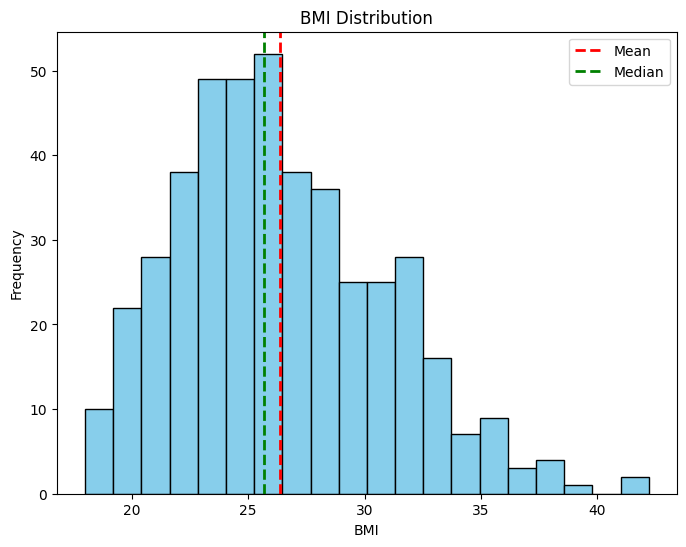

In [ ]:
#PLOT THE DATA DISTRIBUTION

# Calculate the mean, median of the BMI variable
mean = df['BMI'].mean()
median = df['BMI'].median()

# Histogram of the BMI variable
plt.figure(figsize=(8, 6))
plt.hist(df['BMI'], bins=20, color='skyblue', edgecolor='black')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')

# Add lines for the mean and median
plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(median, color='green', linestyle='dashed', linewidth=2, label='Median')

# Add a legend
plt.legend()
plt.show()

From this graph, you're able to observe the range and distribution of BMI in the dataset. For example, most of BMI fall within 23.2 and 29.2, and the data is right skewed.

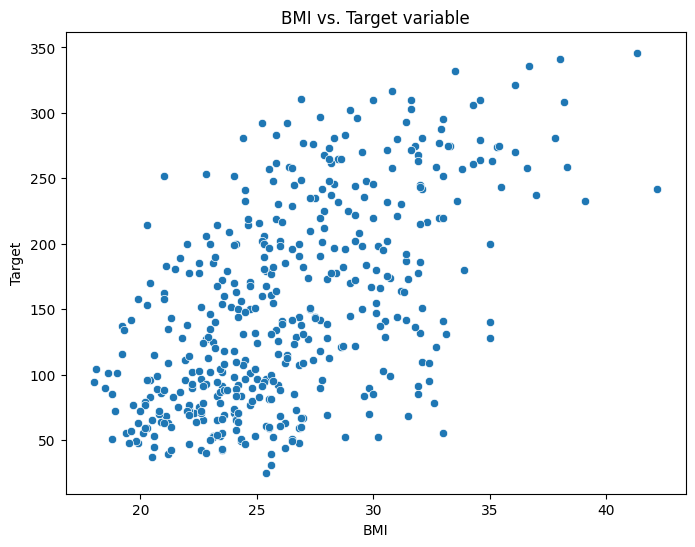

In [ ]:
#MULTIVARIATE ANALYSIS

# Scatter plot of BMI vs. Target variable
plt.figure(figsize=(8, 6))
sns.scatterplot(x='BMI', y='Y', data=df)
plt.title('BMI vs. Target variable')
plt.xlabel('BMI')
plt.ylabel('Target')
plt.show()

We can see that as the BMI increases, the target variable also increases, indicating a positive linear relationship between these two variables.

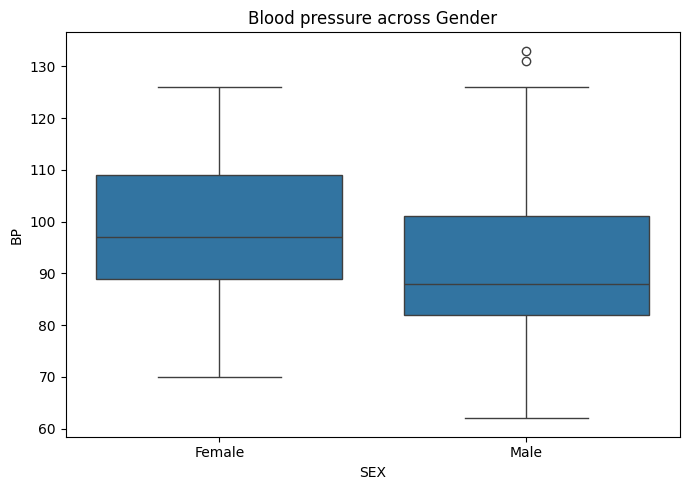

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

# Replace numeric values with labels
df['SEX'] = df['SEX'].replace({1: 'Male', 2: 'Female'})

sns.boxplot(x='SEX', y='BP', data=df, ax=ax)
ax.set_title('Blood pressure across Gender')
plt.tight_layout()
plt.show()

These observations suggest that there are differences in the blood pressure profiles of male and female patients. On average, female patients have a higher blood pressure than male patients.

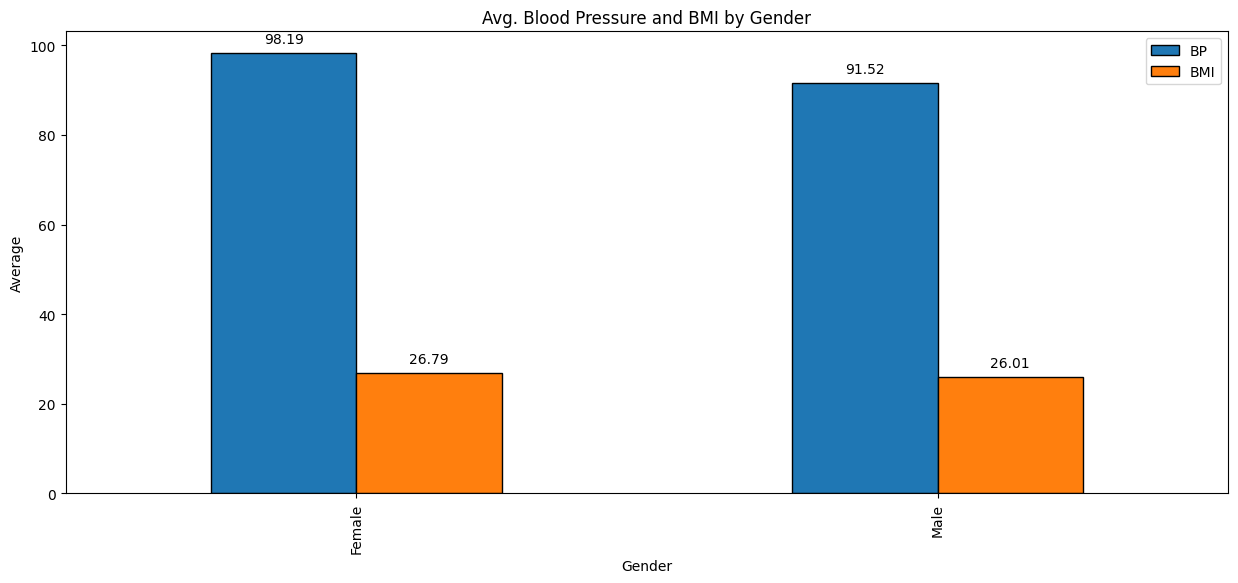

In [ ]:
# Calculate average BP and BMI by SEX
avg_values = df.groupby('SEX')[['BP', 'BMI']].mean()

# Bar chart of the average BP and BMI by SEX
ax = avg_values.plot(kind='bar', figsize=(15, 6), edgecolor='black')

# Add title and labels
plt.title('Avg. Blood Pressure and BMI by Gender')
plt.xlabel('Gender')
plt.ylabel('Average')

# Display actual numbers on the bar chart
for p in ax.patches:
   ax.annotate(format(p.get_height(), '.2f'),
               (p.get_x() + p.get_width() / 2., p.get_height()),
               ha = 'center', va = 'center',
               xytext = (0, 10),
               textcoords = 'offset points')

plt.show()

This graph shows that the average blood pressure is higher in female patients compared to male patients. Additionally, it shows that the average Body Mass Index (BMI) is slightly higher in females than in males.

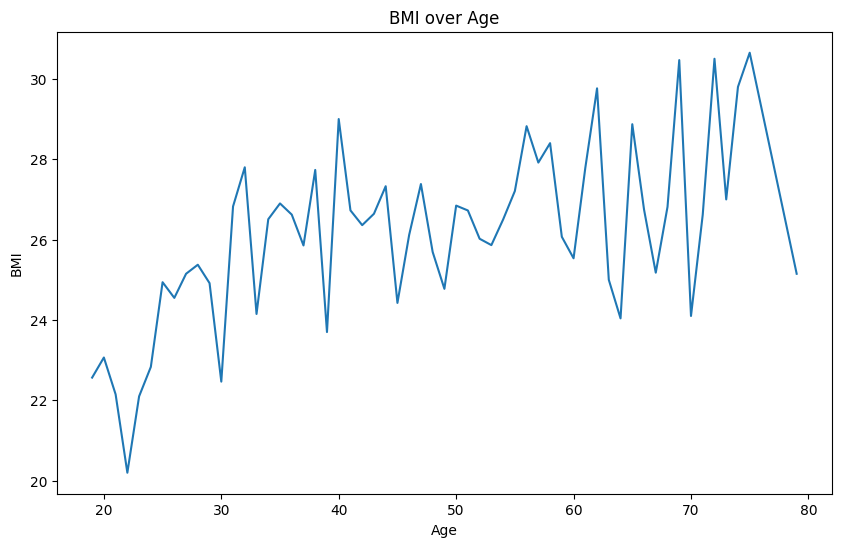

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='AGE', y='BMI', data=df, errorbar=None)
plt.title('BMI over Age')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

The age group of 19 to 30 years has the lowest average BMI values, while the highest average BMI is found in the age group of 65 to 79 years. Additionally, observe that the average BMI for most age groups falls within the overweight range.

<Axes: >

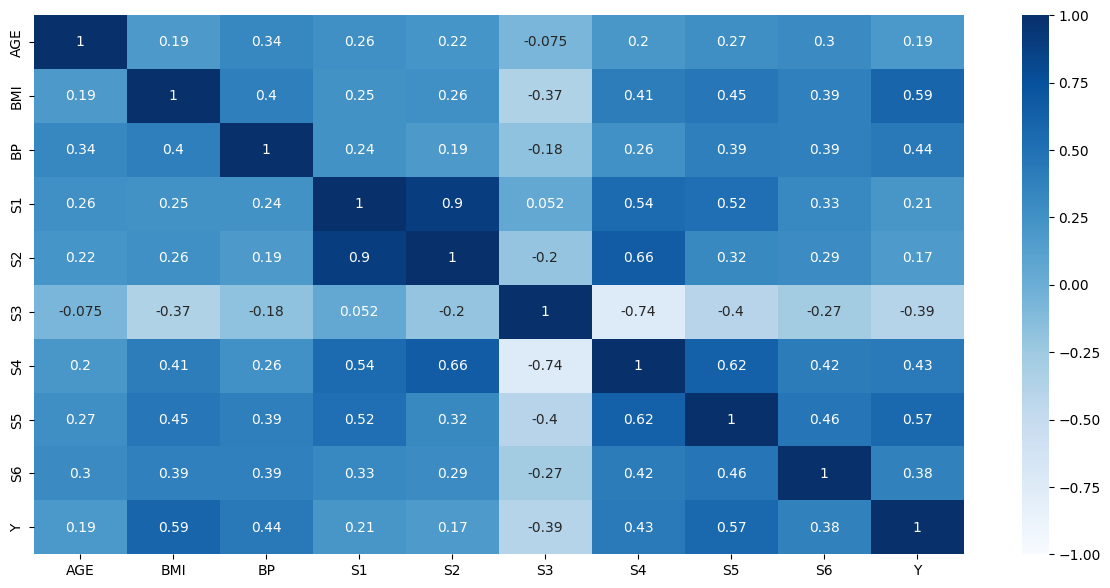

In [ ]:
#CORRELATION ANALYSIS

df.corr(numeric_only=True)
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap="Blues")

###Scaler

In [ ]:
#Create Scaler
scaler=MinMaxScaler(feature_range=(0,1))

###Train a Regression model

In [ ]:
X, y = df_clean[['AGE','SEX','BMI','BP','S1','S2','S3','S4','S5','S6']].values, df_clean['Y'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [ ]:
# Fit + transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled.min())
print(X_train_scaled.max())
print(X_train_scaled.min(axis=0))
print(X_train_scaled.max(axis=0))
print(X_train_scaled)

0.0
1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[[0.55       1.         0.33333333 ... 0.50634697 0.57818807 0.62121212]
 [0.36666667 0.         0.07172996 ... 0.14104372 0.34764295 0.46969697]
 [0.51666667 0.         0.56540084 ... 0.48660085 0.46930394 0.39393939]
 ...
 [0.76666667 0.         0.24894515 ... 0.56417489 0.79023483 1.        ]
 [0.13333333 0.         0.0464135  ... 0.14104372 0.41580961 0.1969697 ]
 [0.68333333 1.         0.61181435 ... 0.42313117 0.76822633 0.81818182]]


In [ ]:
modelR = LinearRegression()
modelR.fit(X_train_scaled, y_train)

LinearRegression()

###Train a Classification model

In [ ]:
X, y = df_clean[['AGE','SEX','BMI','BP','S1','S2','S3','S4','S5','S6']].values, df_clean['Risk'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [ ]:
# Fit + transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data
X_test_scaled = scaler.transform(X_test)

In [ ]:
modelC = LogisticRegression(C=1/0.1, solver="liblinear").fit(X_train_scaled, y_train)

###Train a Decision Tree Regressor

In [ ]:
X, y = df_clean[['AGE','SEX','BMI','BP','S1','S2','S3','S4','S5','S6']].values, df_clean['Y'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [ ]:
# Fit + transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data
X_test_scaled = scaler.transform(X_test)

In [ ]:
modelDT = DecisionTreeRegressor(max_depth=5)
modelDT.fit(X_train_scaled, y_train)


DecisionTreeRegressor(max_depth=5)

###Saving the Model

In [ ]:
#Define the Filename
RegressionModel="RegressionModel"
ClassificationModel="ClassificationModel"
DecisionTreeRegressorModel="DecisionTreeModel"
scalerModel="MinMaxScalerModel"

#Saving the Model
joblib.dump(modelR,RegressionModel)
print("Regression Model Saved")
joblib.dump(modelC,ClassificationModel)
print("Classification Model Saved")
joblib.dump(modelDT,DecisionTreeRegressorModel)
print("Decision Tree Model Saved")

#Saving the Scaler
joblib.dump(scaler,scalerModel)
print("Scaler Model")

Regression Model Saved
Classification Model Saved
Decision Tree Model Saved
Scaler Model


###Test Dataset

In [ ]:
#from pyspark.sql.types import IntegerType, DoubleType

# Create a new dataframe with patient data
data = [
   (62, 2, 33.7, 101.0, 157, 93.2, 38.0, 4.0, 4.8598, 87),
   (50, 1, 22.7, 87.0, 183, 103.2, 70.0, 3.0, 3.8918, 69),
   (76, 2, 32.0, 93.0, 156, 93.6, 41.0, 4.0, 4.6728, 85),
   (25, 1, 26.6, 84.0, 198, 131.4, 40.0, 5.0, 4.8903, 89),
   (53, 1, 23.0, 101.0, 192, 125.4, 52.0, 4.0, 4.2905, 80),
   (24, 1, 23.7, 89.0, 139, 64.8, 61.0, 2.0, 4.1897, 68),
   (38, 2, 22.0, 90.0, 160, 99.6, 50.0, 3.0, 3.9512, 82),
   (69, 2, 27.5, 114.0, 255, 185.0, 56.0, 5.0, 4.2485, 92),
   (63, 2, 33.7, 83.0, 179, 119.4, 42.0, 4.0, 4.4773, 94),
   (30, 1, 30.0, 85.0, 180, 93.4, 43.0, 4.0, 5.3845, 88)
]
columns = ['AGE','SEX','BMI','BP','S1','S2','S3','S4','S5','S6']
df_test=pd.DataFrame(data,columns=columns)
'''
df = spark.createDataFrame(data, schema=columns)

# Convert data types to match the model input schema
df = df.withColumn("AGE", df["AGE"].cast(IntegerType()))
df = df.withColumn("SEX", df["SEX"].cast(IntegerType()))
df = df.withColumn("BMI", df["BMI"].cast(DoubleType()))
df = df.withColumn("BP", df["BP"].cast(DoubleType()))
df = df.withColumn("S1", df["S1"].cast(IntegerType()))
df = df.withColumn("S2", df["S2"].cast(DoubleType()))
df = df.withColumn("S3", df["S3"].cast(DoubleType()))
df = df.withColumn("S4", df["S4"].cast(DoubleType()))
df = df.withColumn("S5", df["S5"].cast(DoubleType()))
df = df.withColumn("S6", df["S6"].cast(IntegerType()))

# Save the data in a delta table
table_name = "diabetes_test"
df.write.format("delta").mode("overwrite").saveAsTable(table_name)
print(f"Spark dataframe saved to delta table: {table_name}")
'''
df_test.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6
0,62,2,33.7,101.0,157,93.2,38.0,4.0,4.8598,87
1,50,1,22.7,87.0,183,103.2,70.0,3.0,3.8918,69
2,76,2,32.0,93.0,156,93.6,41.0,4.0,4.6728,85
3,25,1,26.6,84.0,198,131.4,40.0,5.0,4.8903,89
4,53,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80


###Test the Model

In [ ]:
#REGRESSION MODEL
loaded_model = joblib.load('RegressionModel')
loaded_scaler = joblib.load('MinMaxScalerModel')

# Get the feature names in the correct order as used during training
feature_columns = ['AGE','SEX','BMI','BP','S1','S2','S3','S4','S5','S6']

# Create a DataFrame from the inputs, ensuring correct column order
for row in df_test.itertuples(index=False):
  # Convert the row tuple to a list and then to a DataFrame with 1 row
  input_data = pd.DataFrame([list(row)], columns=feature_columns)

  # Scale the input data using the loaded scaler
  scaled_input = loaded_scaler.transform(input_data)

  # Make prediction (Regression models return a continuous value)
  prediction = loaded_model.predict(scaled_input)

  # Display result
  print(f"Predicted Progression Value: {prediction[0]:.2f}")

Predicted Progression Value: 223.65
Predicted Progression Value: 71.17
Predicted Progression Value: 190.41
Predicted Progression Value: 179.75
Predicted Progression Value: 123.03
Predicted Progression Value: 118.88
Predicted Progression Value: 78.55
Predicted Progression Value: 121.37
Predicted Progression Value: 175.79
Predicted Progression Value: 227.54


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler 

In [ ]:
#CLASSIFICATION MODEL
loaded_model = joblib.load('ClassificationModel')
loaded_scaler = joblib.load('MinMaxScalerModel')

# Get the feature names in the correct order as used during training
feature_columns = ['AGE','SEX','BMI','BP','S1','S2','S3','S4','S5','S6']

# Create a DataFrame from the inputs, ensuring correct column order
for row in df_test.itertuples(index=False):
  # Convert the row tuple to a list and then to a DataFrame with 1 row
  input_data = pd.DataFrame([list(row)], columns=feature_columns)

  # Scale the input data using the loaded scaler
  scaled_input = loaded_scaler.transform(input_data)

  # Make prediction
  prediction = loaded_model.predict(scaled_input)

  # Display result using a ternary operator and corrected quotes
  risk_label = 'Yes' if prediction[0] == 1 else 'No'
  print(f"High Risk Prediction: {risk_label}")

High Risk Prediction: Yes
High Risk Prediction: No
High Risk Prediction: No
High Risk Prediction: No
High Risk Prediction: No
High Risk Prediction: No
High Risk Prediction: No
High Risk Prediction: No
High Risk Prediction: No
High Risk Prediction: Yes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler 

In [ ]:
#Decision Tree Model
loaded_model = joblib.load('DecisionTreeModel')
loaded_scaler = joblib.load('MinMaxScalerModel')

# Get the feature names in the correct order as used during training
feature_columns = ['AGE','SEX','BMI','BP','S1','S2','S3','S4','S5','S6']

# Create a DataFrame from the inputs, ensuring correct column order
for row in df_test.itertuples(index=False):
  # Convert the row tuple to a list and then to a DataFrame with 1 row
  input_data = pd.DataFrame([list(row)], columns=feature_columns)

  # Scale the input data using the loaded scaler
  scaled_input = loaded_scaler.transform(input_data)

  # Make prediction (Regression models return a continuous value)
  prediction = loaded_model.predict(scaled_input)

  # Display result
  print(f"Predicted Progression Value: {prediction[0]:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler 

Predicted Progression Value: 143.60
Predicted Progression Value: 76.98
Predicted Progression Value: 143.60
Predicted Progression Value: 166.82
Predicted Progression Value: 122.11
Predicted Progression Value: 76.98
Predicted Progression Value: 75.50
Predicted Progression Value: 52.00
Predicted Progression Value: 143.60
Predicted Progression Value: 255.36
